In [126]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [127]:
df = pd.read_csv("CC GENERAL.csv")
print(f"Total rows in dataset: {df.shape[0]}")
print(f"Total columns in dataset: {df.shape[1]}")

Total rows in dataset: 8950
Total columns in dataset: 18


## INSPECT DATA

In [128]:
df.sample(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3715,C13821,3177.742619,1.000000,153.72,153.72,0.00,0.000000,0.416667,0.416667,0.000000,0.000000,0,5,3500.0,1078.780479,780.955903,0.000000,12
3222,C13316,784.897871,1.000000,0.00,0.00,0.00,312.283682,0.000000,0.000000,0.000000,0.166667,3,0,1600.0,287.326954,269.699364,0.000000,12
2136,C12203,146.756706,1.000000,1664.95,64.17,1600.78,0.000000,1.000000,0.166667,1.000000,0.000000,0,55,4000.0,1458.490552,188.635203,0.750000,12
2121,C12187,1189.665497,0.909091,0.00,0.00,0.00,1454.884966,0.000000,0.000000,0.000000,0.083333,3,0,1500.0,1656.765938,364.185880,0.000000,12
7951,C18166,888.101401,1.000000,100.00,0.00,100.00,896.578990,0.222222,0.000000,0.111111,0.111111,2,2,1000.0,212.755352,527.241583,0.000000,9
2160,C12227,68.208380,0.272727,780.00,780.00,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,2,3200.0,196.173726,14.037214,0.000000,12
4573,C14699,152.459665,1.000000,1248.09,829.45,418.64,0.000000,1.000000,1.000000,0.250000,0.000000,0,21,5000.0,1316.455236,210.906103,0.166667,12
5255,C15402,7907.725211,1.000000,1685.19,1552.31,132.88,8253.390661,0.833333,0.750000,0.166667,0.416667,14,27,18500.0,19841.257370,2025.836483,0.090909,12
2944,C13031,6.149295,0.181818,169.01,0.00,169.01,0.000000,0.250000,0.000000,0.250000,0.000000,0,3,10000.0,731.852542,128.525835,0.666667,12
4953,C15092,798.693995,1.000000,0.00,0.00,0.00,1865.808018,0.000000,0.000000,0.000000,0.666667,11,0,3000.0,180.865117,301.842645,0.000000,12


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [130]:
df.isnull().sum().rename("Missing Values").to_frame().sort_values(by="Missing Values", ascending=False)

,Missing Values
MINIMUM_PAYMENTS,313
CREDIT_LIMIT,1
CUST_ID,0
BALANCE,0
PRC_FULL_PAYMENT,0
PAYMENTS,0
PURCHASES_TRX,0
CASH_ADVANCE_TRX,0
CASH_ADVANCE_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [131]:
df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median(), inplace=True)
df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median(), inplace=True)

In [132]:
(df["MINIMUM_PAYMENTS"].isnull().mean()) * 100

np.float64(0.0)

In [133]:
df.duplicated().sum()

np.int64(0)

### Exploratory Analysis (EDA)

In [134]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.282473,1733.143852,844.906767,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.646702,2895.063757,2332.792322,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,170.857654,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,788.713501,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [135]:
sns.set_style("whitegrid")

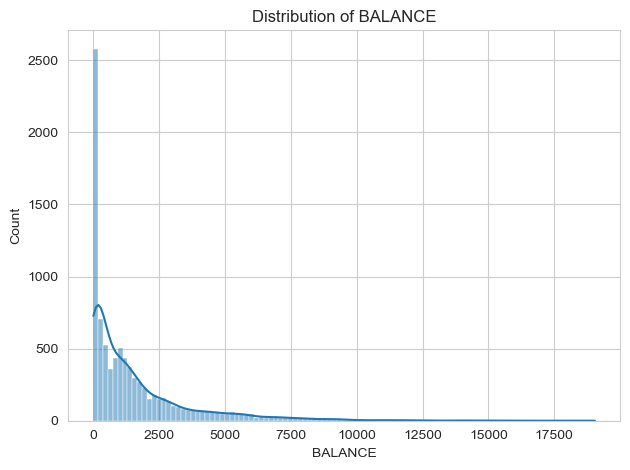

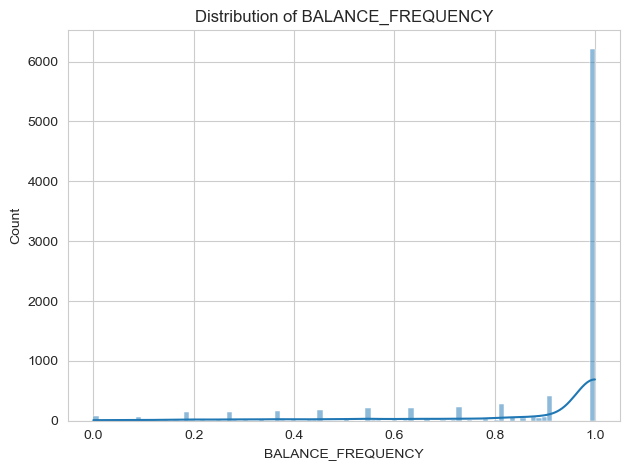

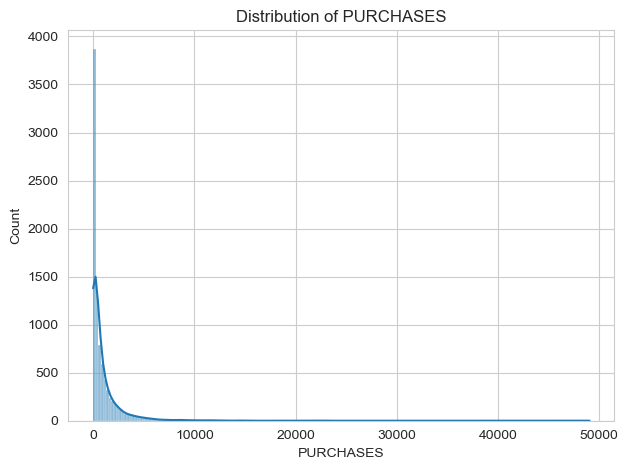

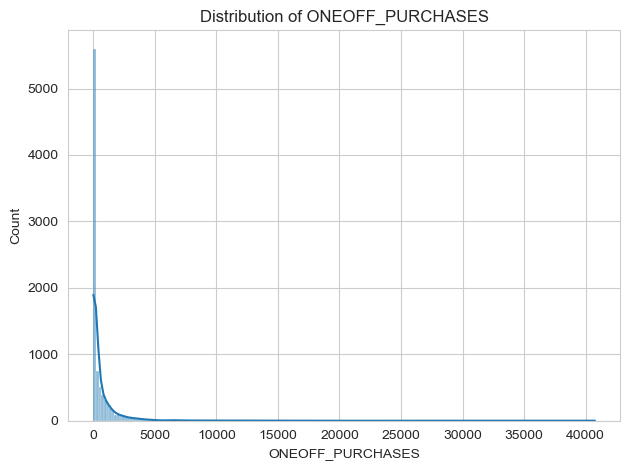

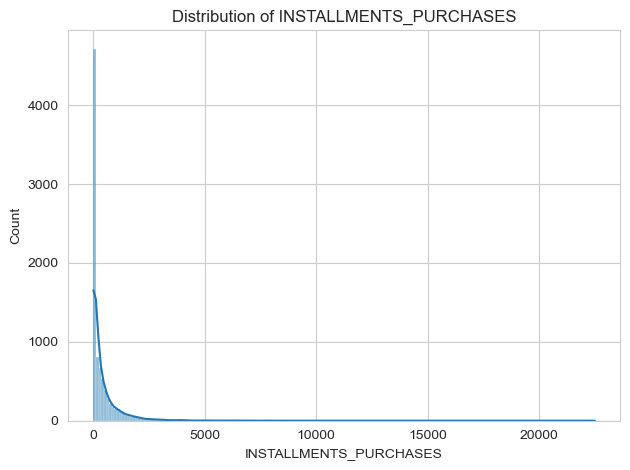

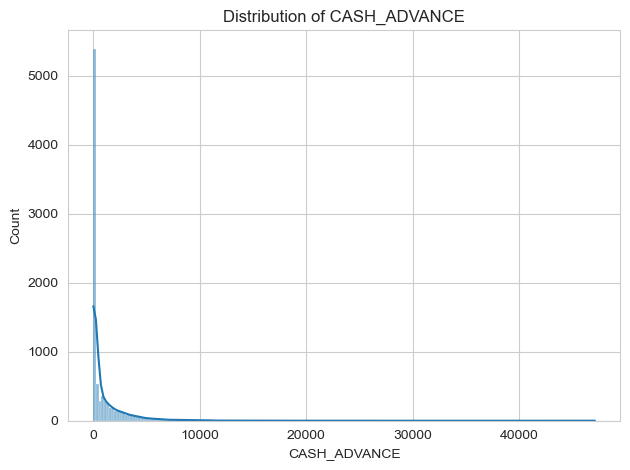

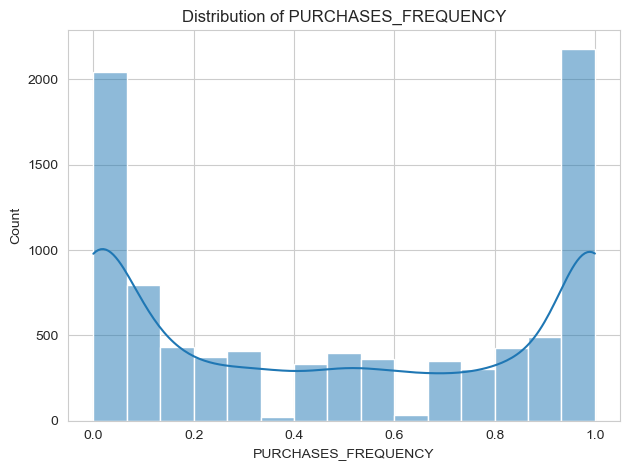

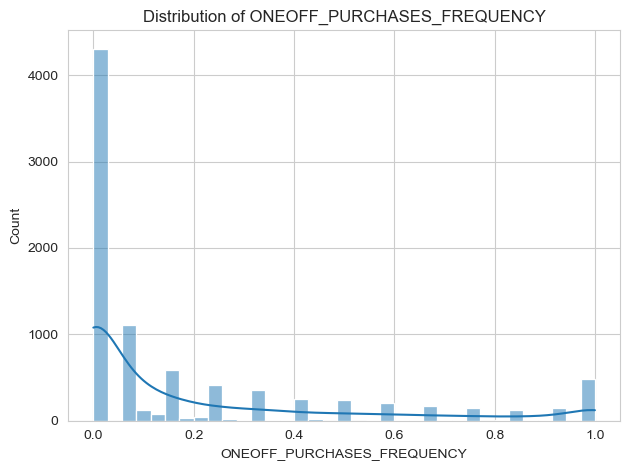

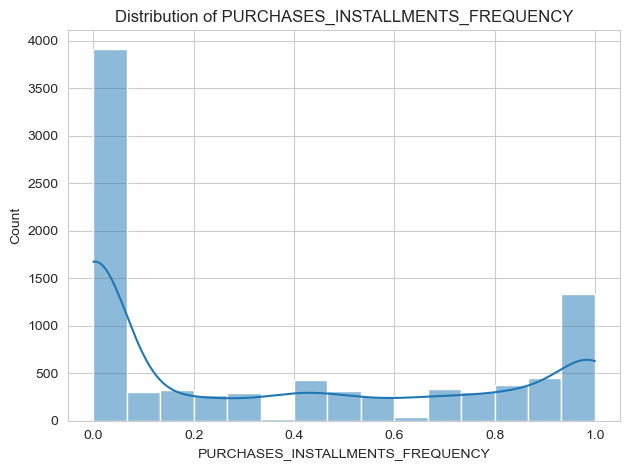

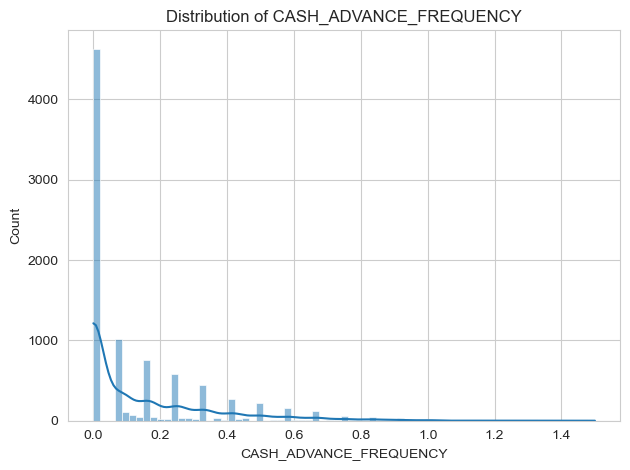

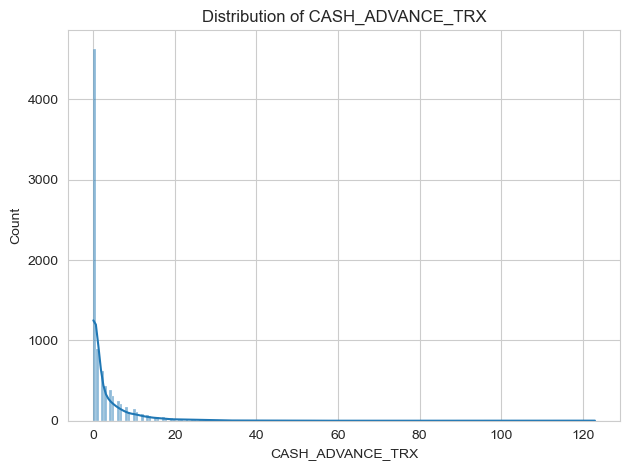

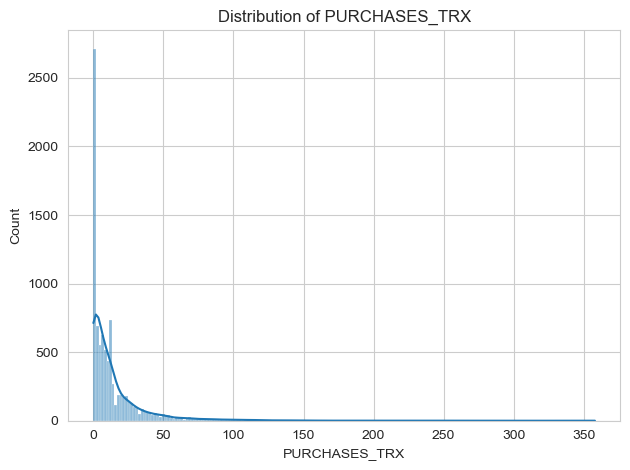

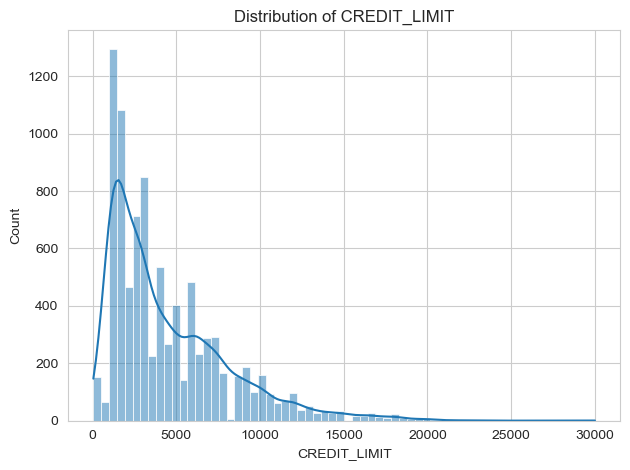

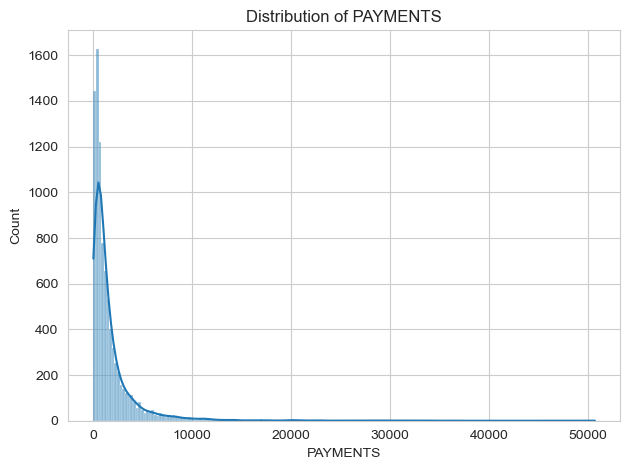

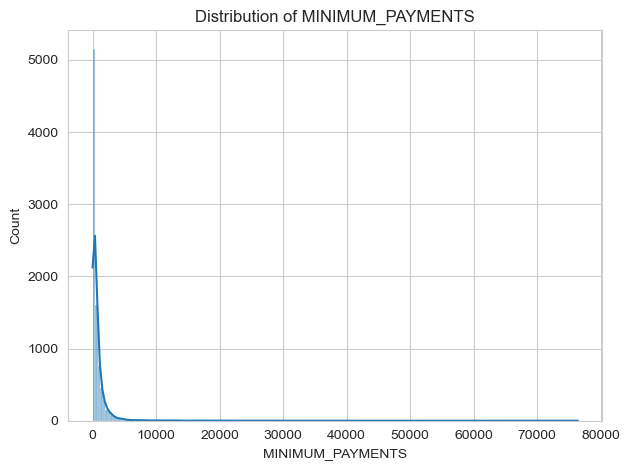

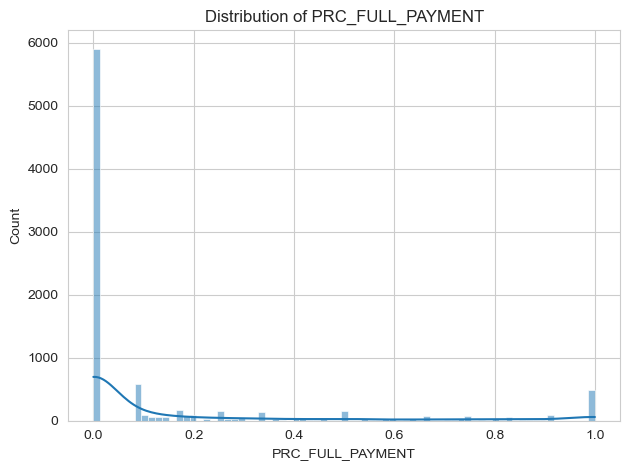

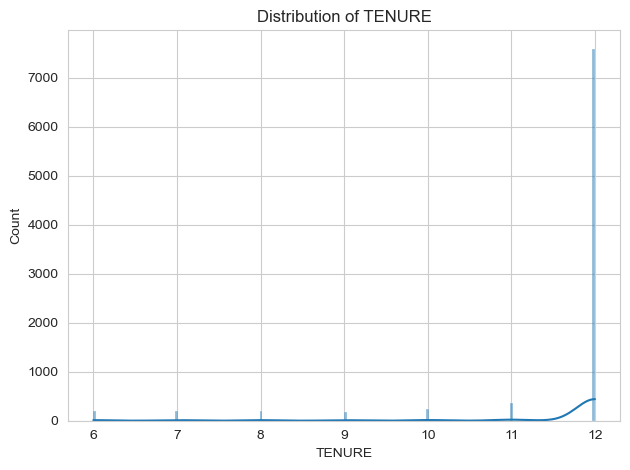

In [136]:
for col in df.select_dtypes(exclude="object"):
    plt.Figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

In [137]:
def outlier_check(df, columns=None, factor=1.5):
    """Detect outliers across specified columns using IQR.

    Parameters:
    - df (pd.DataFrame): The input dataframe.
    - columns (list): List of column names to check.
    - factor (float): The IQR multiplier.
    """

    if columns is None:
        columns = df.select_dtypes(exclude="object").columns

    summary_data = []
    outlier_indices = {}

    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - (factor * iqr)
        upper_bound = q3 + (factor * iqr)

        outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_indices[col] = outlier.index.to_list()

        count_outlier = len(outlier)
        perct_outlier = (count_outlier / len(df)) * 100

        summary_data.append(
            {
                "column": col,
                "Outlier count": count_outlier,
                "Percentage of Outliers": perct_outlier,
                "Lower Bound": lower_bound,
                "Upper Bound": upper_bound,
            }
        )

    summary_df = pd.DataFrame(summary_data)
    return summary_df, outlier_indices

In [138]:
outlier_check(df)

(                              column  Outlier count  Percentage of Outliers  \
 0                            BALANCE            695                7.765363   
 1                  BALANCE_FREQUENCY           1493               16.681564   
 2                          PURCHASES            808                9.027933   
 3                   ONEOFF_PURCHASES           1013               11.318436   
 4             INSTALLMENTS_PURCHASES            867                9.687151   
 5                       CASH_ADVANCE           1030               11.508380   
 6                PURCHASES_FREQUENCY              0                0.000000   
 7         ONEOFF_PURCHASES_FREQUENCY            782                8.737430   
 8   PURCHASES_INSTALLMENTS_FREQUENCY              0                0.000000   
 9             CASH_ADVANCE_FREQUENCY            525                5.865922   
 10                  CASH_ADVANCE_TRX            804                8.983240   
 11                     PURCHASES_TRX   

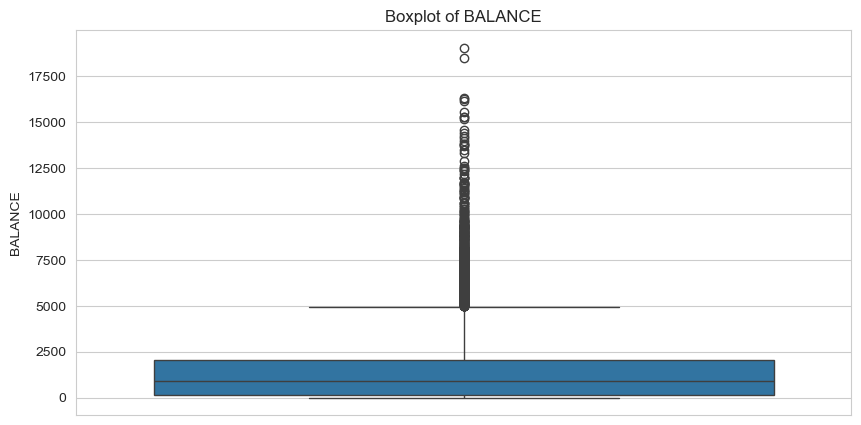

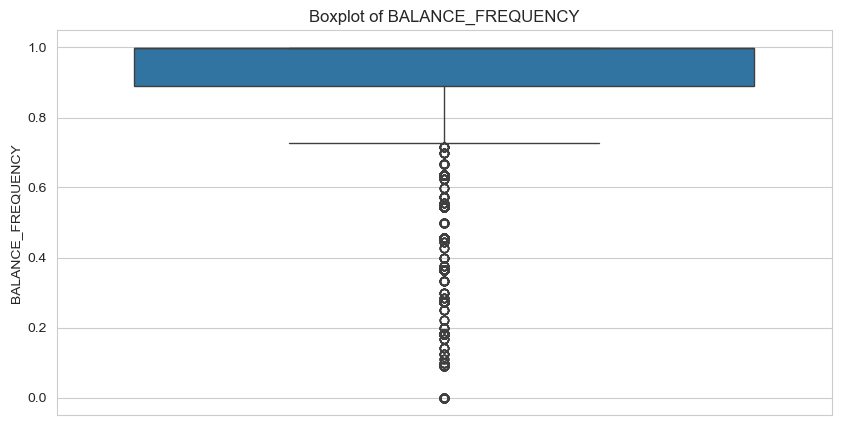

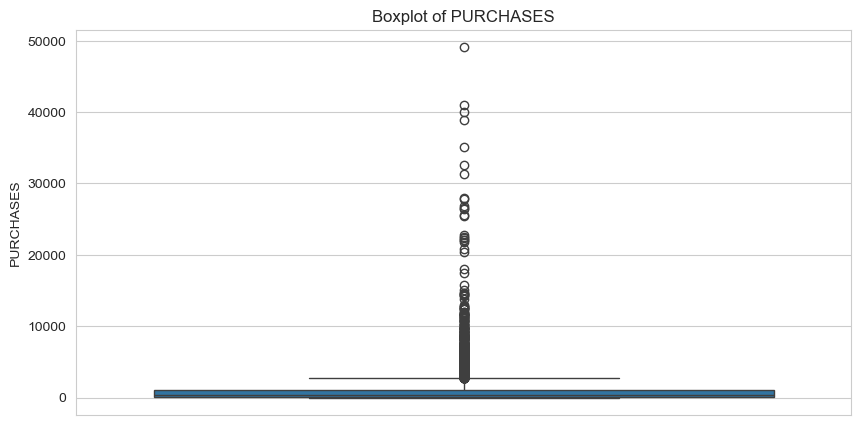

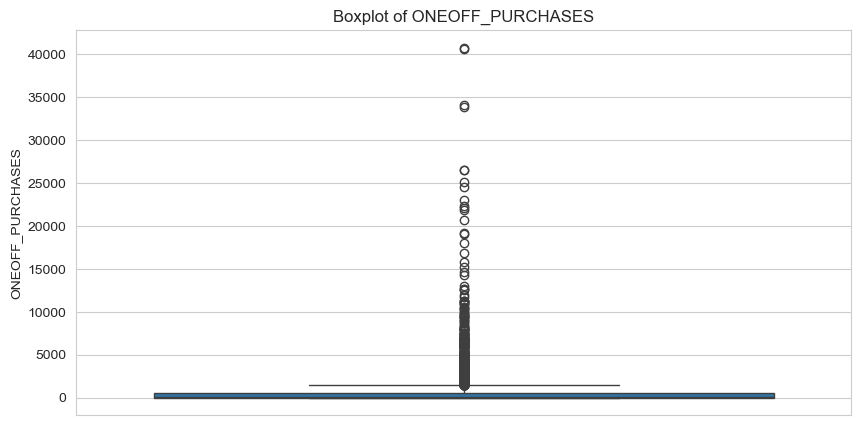

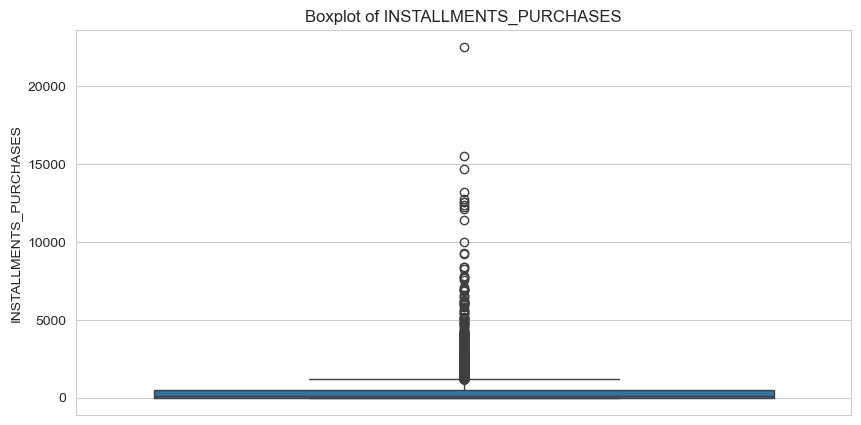

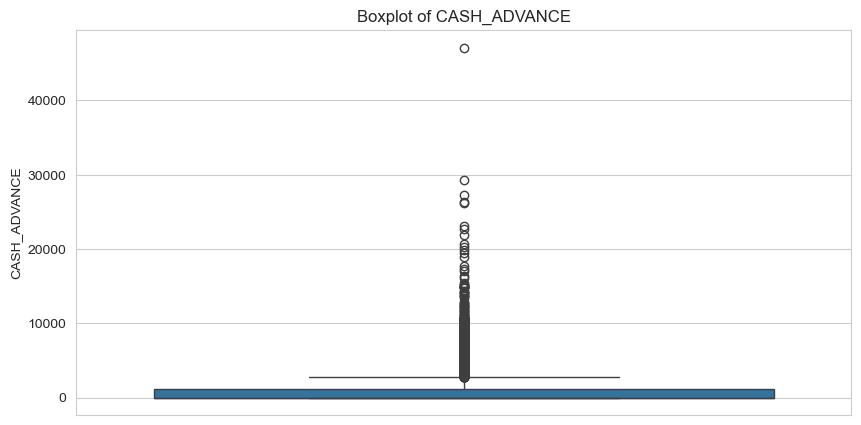

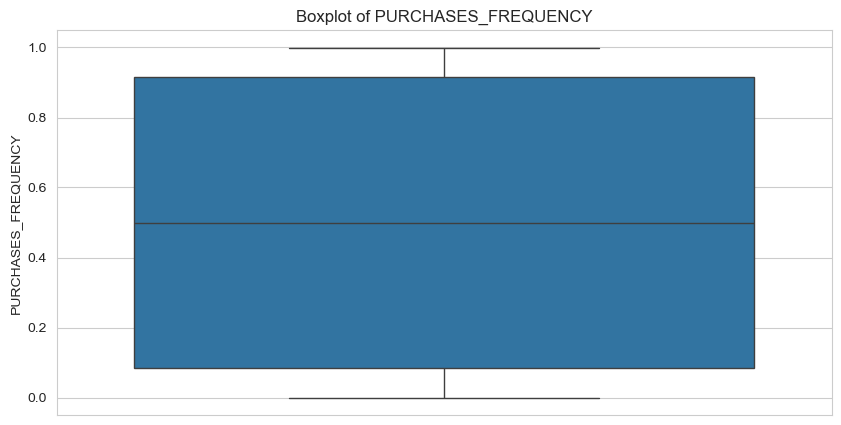

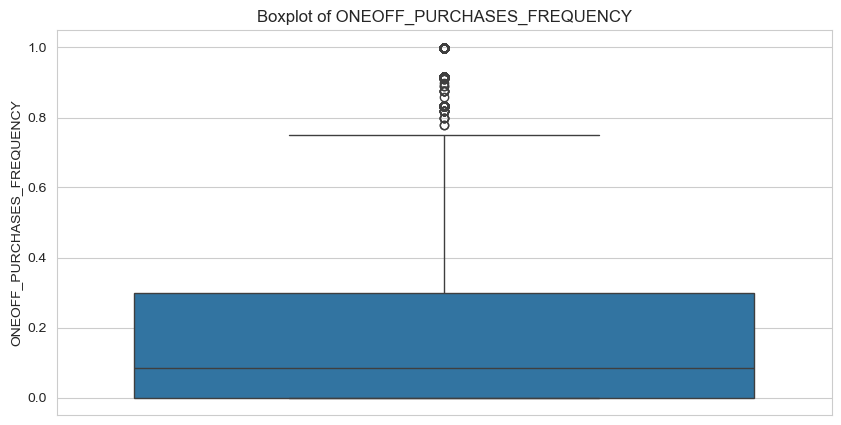

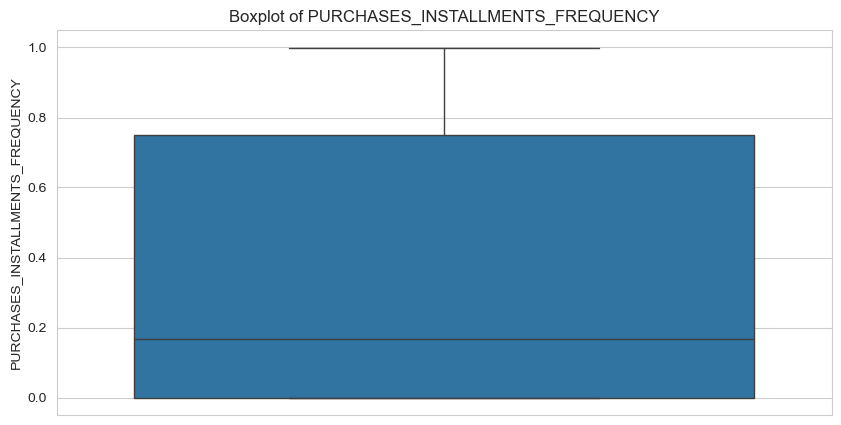

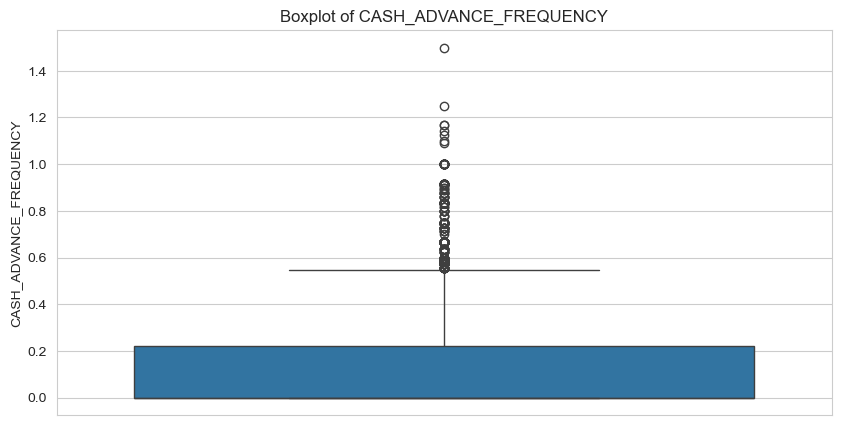

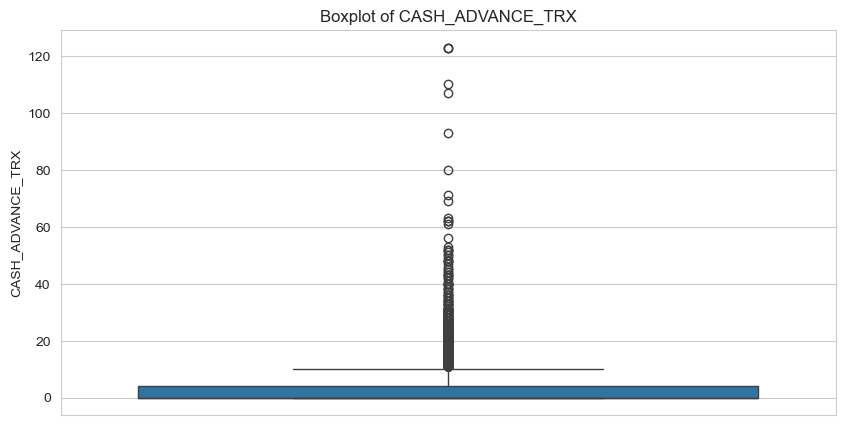

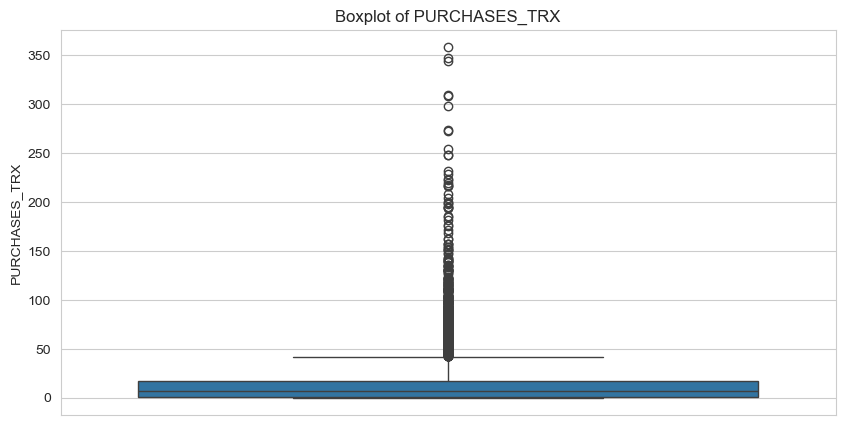

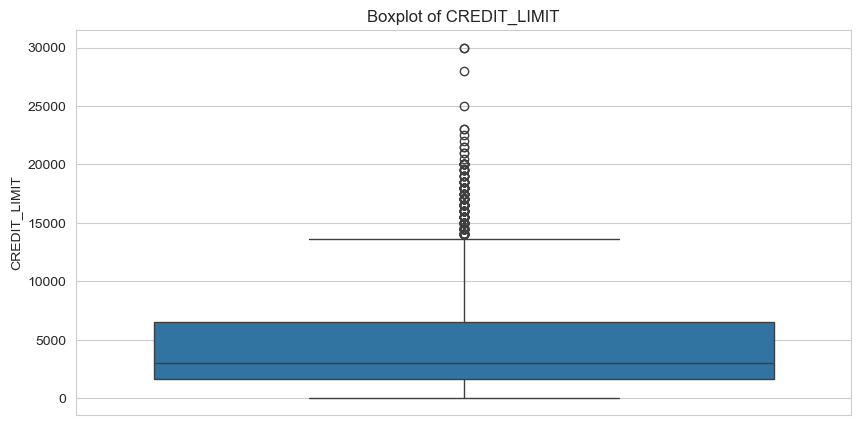

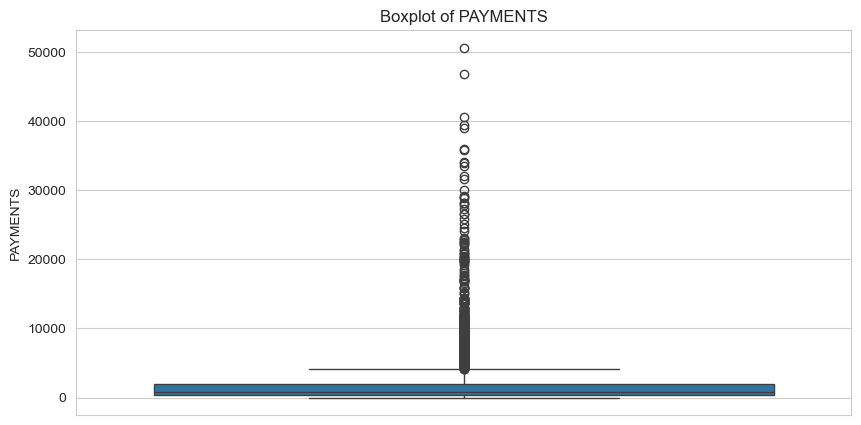

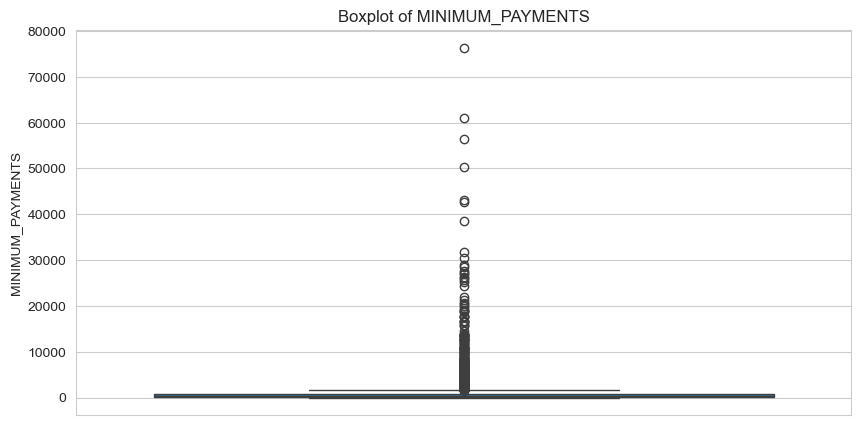

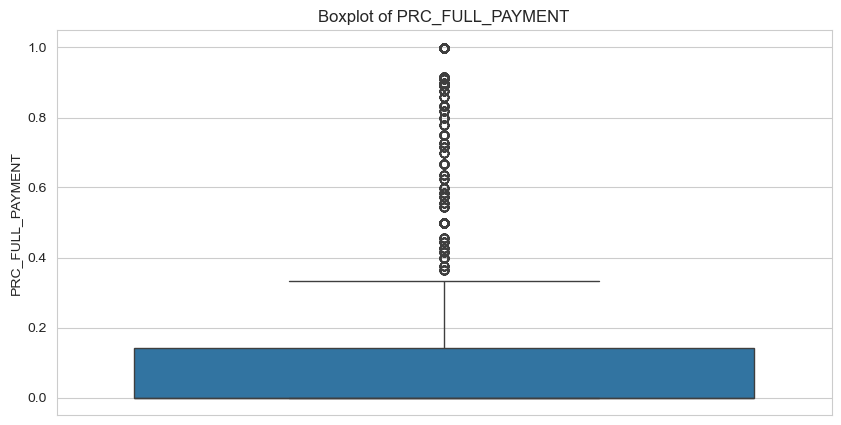

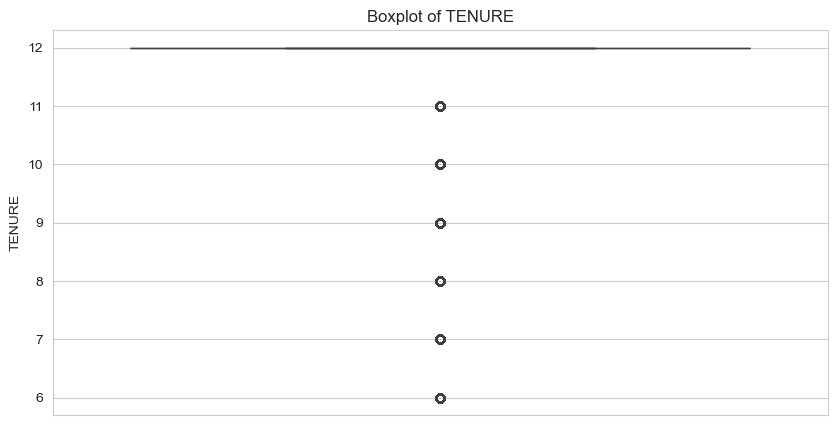

In [139]:
#suspected outliers

for col in df.select_dtypes(exclude="object"):
    plt.figure(figsize=(10, 5))
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Feature Engineering

In [140]:
df["cash_advance_ratio"] = df["CASH_ADVANCE"] / (df["PAYMENTS"] + 1)
df["oneoff_ratio"] = df["ONEOFF_PURCHASES"] / (df["PURCHASES"] + 1)
df["installment_ratio"] = df["INSTALLMENTS_PURCHASES"] / (df["PURCHASES"] + 1)
df["balance_to_limit"] = df["BALANCE"] / (df["CREDIT_LIMIT"] + 1)

In [141]:
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,...,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cash_advance_ratio,oneoff_ratio,installment_ratio,balance_to_limit
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,...,2,1000.0,201.802084,139.509787,0.000000,12,0.000000,0.000000,0.989627,0.040860
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,...,0,7000.0,4103.032597,1072.340217,0.222222,12,1.569906,0.000000,0.000000,0.457430
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,...,12,7500.0,622.066742,627.284787,0.000000,12,0.000000,0.998708,0.000000,0.332642
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,...,1,7500.0,0.000000,312.343947,0.000000,12,205.788017,0.999333,0.000000,0.222193
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,...,1,1200.0,678.334763,244.791237,0.000000,12,0.000000,0.941176,0.000000,0.680861
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,...,6,1000.0,325.594462,48.886365,0.500000,6,0.000000,0.000000,0.996577,0.028465
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,...,6,1000.0,275.861322,312.343947,0.000000,6,0.000000,0.000000,0.996678,0.019164
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,...,5,1000.0,81.270775,82.418369,0.250000,6,0.000000,0.000000,0.993122,0.023375
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,...,0,500.0,52.549959,55.755628,0.250000,6,0.682704,0.000000,0.000000,0.026861


In [142]:
df.corr(numeric_only=True)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cash_advance_ratio,oneoff_ratio,installment_ratio,balance_to_limit
BALANCE,1.000000,0.322412,0.181261,0.164350,0.126469,0.496692,-0.077944,0.073166,-0.063186,0.449218,...,0.154338,0.531296,0.322802,0.397920,-0.318959,0.072692,0.015969,0.030035,-0.054011,0.505633
BALANCE_FREQUENCY,0.322412,1.000000,0.133674,0.104323,0.124292,0.099388,0.229715,0.202415,0.176079,0.191873,...,0.189626,0.095931,0.065008,0.131181,-0.095082,0.119776,-0.091505,0.038524,-0.017024,0.406089
PURCHASES,0.181261,0.133674,1.000000,0.916845,0.679896,-0.051474,0.393017,0.498430,0.315567,-0.120143,...,0.689561,0.356977,0.603264,0.095789,0.180379,0.086288,-0.026726,0.236181,0.004786,-0.057495
ONEOFF_PURCHASES,0.164350,0.104323,0.916845,1.000000,0.330622,-0.031326,0.264937,0.524891,0.127729,-0.082628,...,0.545523,0.319735,0.567292,0.050256,0.132763,0.064150,-0.016391,0.354919,-0.083806,-0.042264
INSTALLMENTS_PURCHASES,0.126469,0.124292,0.679896,0.330622,1.000000,-0.064244,0.442418,0.214042,0.511351,-0.132318,...,0.628108,0.256515,0.384084,0.134019,0.182569,0.086143,-0.033086,-0.093512,0.166216,-0.058373
CASH_ADVANCE,0.496692,0.099388,-0.051474,-0.031326,-0.064244,1.000000,-0.215507,-0.086754,-0.177070,0.628522,...,-0.075850,0.303997,0.453238,0.140747,-0.152935,-0.068312,0.083296,-0.069286,-0.081729,0.215921
PURCHASES_FREQUENCY,-0.077944,0.229715,0.393017,0.264937,0.442418,-0.215507,1.000000,0.501343,0.862934,-0.308478,...,0.568430,0.119833,0.103464,0.006154,0.305802,0.061506,-0.076084,0.091623,0.271441,-0.202367
ONEOFF_PURCHASES_FREQUENCY,0.073166,0.202415,0.498430,0.524891,0.214042,-0.086754,0.501343,1.000000,0.142329,-0.111716,...,0.544869,0.295059,0.243537,-0.027311,0.157531,0.082466,-0.031806,0.614941,-0.130576,-0.092214
PURCHASES_INSTALLMENTS_FREQUENCY,-0.063186,0.176079,0.315567,0.127729,0.511351,-0.177070,0.862934,0.142329,1.000000,-0.262958,...,0.529975,0.060794,0.085551,0.032055,0.250087,0.073275,-0.063520,-0.231565,0.356864,-0.161897
CASH_ADVANCE_FREQUENCY,0.449218,0.191873,-0.120143,-0.082628,-0.132318,0.628522,-0.308478,-0.111716,-0.262958,1.000000,...,-0.131168,0.132608,0.183192,0.100616,-0.249773,-0.133372,0.036629,-0.075154,-0.142172,0.361347


In [143]:
CBS = df.set_index("CUST_ID")[[
    "BALANCE", "balance_to_limit", "oneoff_ratio",
    "installment_ratio", "cash_advance_ratio", "PRC_FULL_PAYMENT", "TENURE"
]].rename(columns={
    "BALANCE": "Balance",
    "balance_to_limit": "Balance_Behavior",
    "oneoff_ratio": "One_off_ratio",
    "installment_ratio": "Installment_ratio",
    "cash_advance_ratio": "Cash_behavior",
    "PRC_FULL_PAYMENT": "Full_payment_rate",
    "TENURE": "Tenure"
})

CBS.sort_values("Balance", ascending=False)

,Balance,Balance_Behavior,One_off_ratio,Installment_ratio,Cash_behavior,Full_payment_rate,Tenure
CUST_ID,,,,,,,
C10144,19043.13856,1.057893,0.429290,0.570664,0.000000,0.0,12
C14256,18495.55855,0.840669,0.691455,0.308356,0.000000,0.0,12
C15642,16304.88925,0.858107,0.000000,0.999436,1.390550,0.0,12
C16812,16259.44857,0.903253,0.712829,0.286972,0.065895,0.0,12
C15429,16115.59640,0.895261,0.153557,0.844985,1.227496,0.0,12
...,...,...,...,...,...,...,...
C13209,0.00000,0.000000,0.986043,0.000000,0.000000,0.0,12
C17643,0.00000,0.000000,0.000000,0.996678,0.000000,0.0,12
C13159,0.00000,0.000000,0.000000,0.984448,0.000000,0.0,12


In [144]:
CBS["Full_payment_rate"].value_counts()

Full_payment_rate
0.000000    5903
1.000000     488
0.083333     426
0.166667     166
0.500000     156
0.250000     156
0.090909     153
0.333333     134
0.100000      94
0.200000      83
0.666667      78
0.916667      77
0.181818      75
0.750000      68
0.833333      63
0.111111      61
0.142857      54
0.125000      52
0.416667      44
0.400000      42
0.300000      40
0.454545      36
0.272727      35
0.800000      33
0.363636      32
0.583333      31
0.600000      28
0.545455      27
0.636364      26
0.285714      24
0.727273      22
0.222222      20
0.909091      19
0.714286      19
0.777778      19
0.875000      18
0.444444      17
0.818182      17
0.900000      16
0.428571      14
0.571429      14
0.375000      13
0.857143      12
0.700000      12
0.888889      12
0.555556      12
0.625000       9
Name: count, dtype: int64

### CUSTOMER BEHAVIORAL SEGMENTATION

In [145]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MiniBatchKMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [146]:
X = CBS[[
    "Balance", "Balance_Behavior", "One_off_ratio",
    "Installment_ratio", "Cash_behavior", "Full_payment_rate", "Tenure"
]]
X_scaled = StandardScaler().fit_transform(X.apply(np.log1p))
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled

,Balance,Balance_Behavior,One_off_ratio,Installment_ratio,Cash_behavior,Full_payment_rate,Tenure
0,-1.205218,-1.022996,-0.919551,1.327995,-0.497788,-0.556368,0.347262
1,0.948918,0.322598,-0.919551,-0.939842,0.514216,0.391958,0.347262
2,0.824993,-0.035203,1.400418,-0.939842,-0.497788,-0.556368,0.347262
3,0.624653,-0.381034,1.401465,-0.939842,5.218783,-0.556368,0.347262
4,0.271260,0.892736,1.302571,-0.939842,-0.497788,-0.556368,0.347262
...,...,...,...,...,...,...,...
8945,-1.379634,-1.070882,-0.919551,1.339491,-0.497788,1.359774,-4.401425
8946,-1.568051,-1.107197,-0.919551,1.339657,-0.497788,-0.556368,-4.401425
8947,-1.473834,-1.090714,-0.919551,1.333782,-0.497788,0.498161,-4.401425
8948,-1.733775,-1.077120,-0.919551,-0.939842,0.060181,0.498161,-4.401425


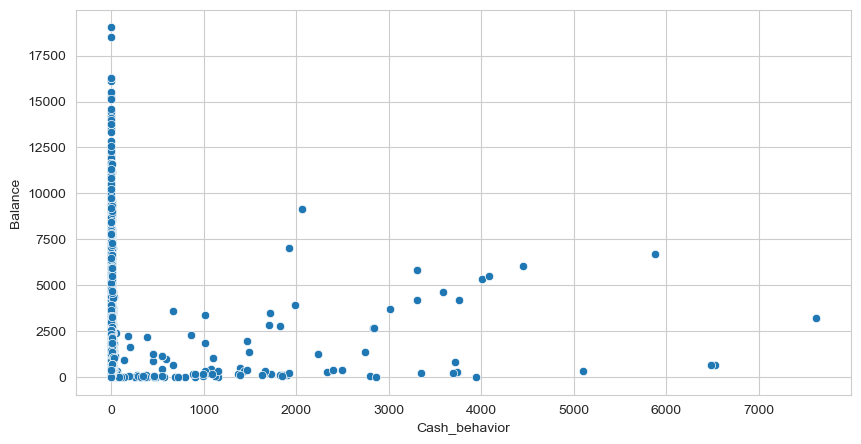

In [147]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    CBS,
    x = "Cash_behavior",
    y = "Balance",
    palette="set1"
)
plt.show()

### Dimensionality Reduction (Principal Components Analysis (PCA))

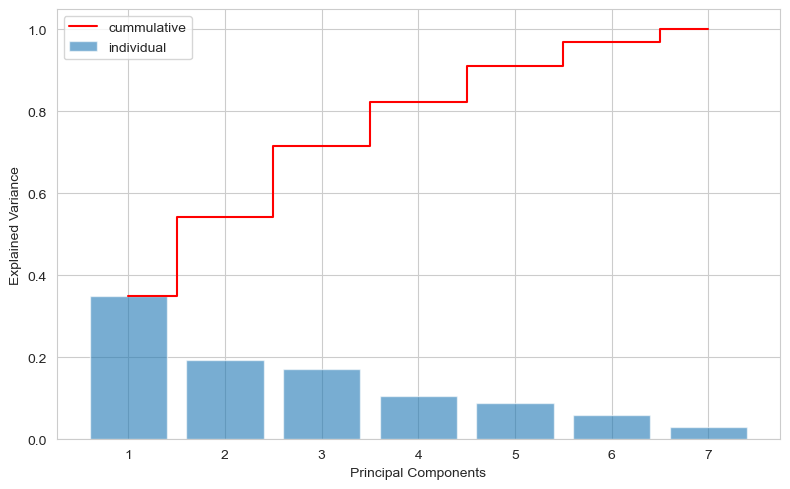

Explained Variance by each components: [0.35  0.193 0.172 0.107 0.089 0.058 0.031]
Cummulative sum of each components: [0.35  0.543 0.716 0.822 0.911 0.969 1.   ]


In [148]:
pca = PCA()
pca.fit_transform(X_scaled)

explain_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explain_var)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explain_var)+1), explain_var, alpha=0.6, label="individual")
plt.step(range(1, len(cum_var)+1), cum_var, where='mid',color='red', label="cummulative")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Explained Variance by each components: {np.round(explain_var, 3)}")
print(f"Cummulative sum of each components: {np.round(cum_var, 3)}")

In [149]:
d = np.argmax(cum_var >= 0.95) + 1
print(f"Number of components to keep to explain 95% variance: {d}")

Number of components to keep to explain 95% variance: 6


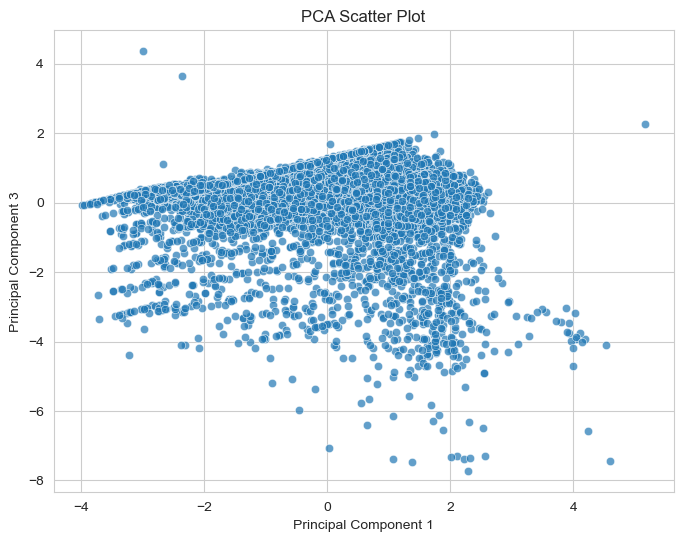

In [150]:
pca_d = PCA(n_components=6)
X_pca =pca_d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 2],cmap='viridis', alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 3")
plt.title("PCA Scatter Plot")
plt.show()

In [151]:
loading = pd.DataFrame(
    pca_d.components_.T,
    columns=['PC1','PC2','PC3','PC4','PC5',"PC6"],
    index=["Balance","Balance_Behavior","One_off_ratio","Installment_ratio", "Cash_behavior", "Full_payment_rate", "Tenure"]
)
loading

,PC1,PC2,PC3,PC4,PC5,PC6
Balance,0.535069,-0.076477,0.221196,-0.189132,0.395956,0.196655
Balance_Behavior,0.528954,-0.217473,0.229493,-0.249995,0.215538,-0.103371
One_off_ratio,0.135146,0.761572,-0.075220,-0.165933,-0.037346,0.574020
Installment_ratio,-0.367980,-0.495110,0.295921,-0.202378,-0.073668,0.692286
Cash_behavior,0.279411,-0.268305,-0.538524,0.619461,0.160304,0.372669
Full_payment_rate,-0.449576,0.117660,-0.077098,-0.028662,0.872788,-0.050369
Tenure,-0.006839,0.189471,0.713600,0.669841,0.049833,0.021507


### KMeans Cluster

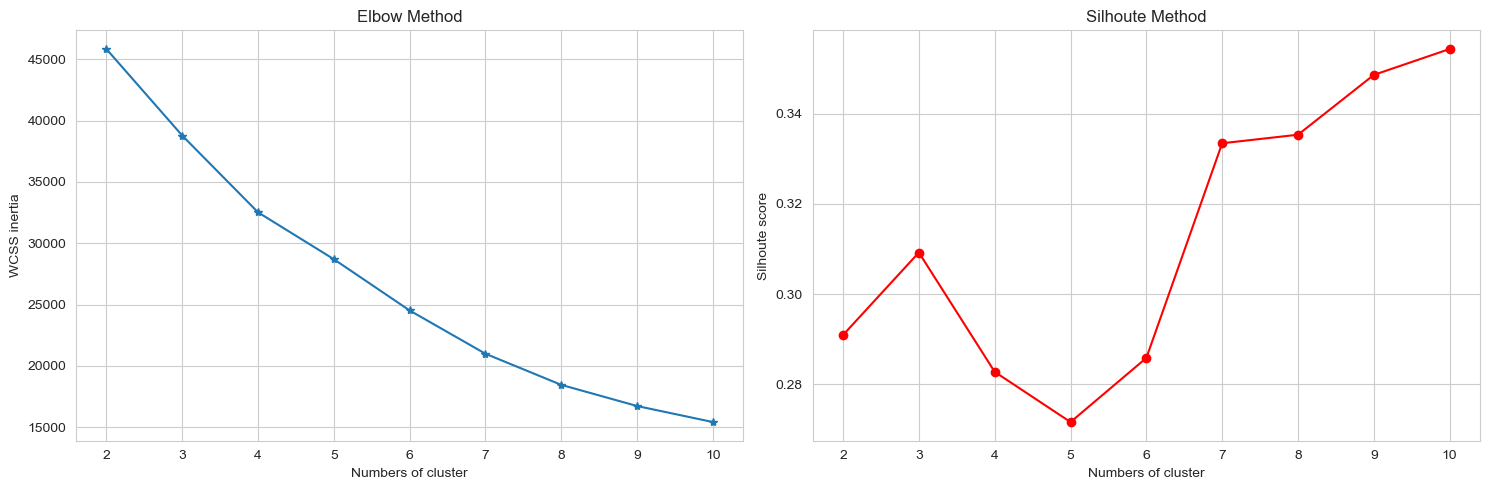

In [152]:
wcss = []
sil_score = []
k_range = range(2, 11)

for k in k_range:
    km =KMeans(n_clusters=k,random_state=42, n_init=10)
    label = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_score.append(silhouette_score(X_scaled, label))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(list(k_range), wcss, marker="*")
ax[0].set_xlabel("Numbers of cluster")
ax[0].set_ylabel("WCSS inertia")
ax[0].set_title("Elbow Method")
ax[1].plot(list(k_range), sil_score, marker="o", color='red')
ax[1].set_xlabel("Numbers of cluster")
ax[1].set_ylabel("Silhoute score")
ax[1].set_title("Silhoute Method")
plt.tight_layout()
plt.show()


In [153]:
for k, s in zip(k_range,sil_score):
    print(f"K = {k},silhoute={s:.3f}")

K = 2,silhoute=0.291
K = 3,silhoute=0.309
K = 4,silhoute=0.283
K = 5,silhoute=0.272
K = 6,silhoute=0.286
K = 7,silhoute=0.333
K = 8,silhoute=0.335
K = 9,silhoute=0.349
K = 10,silhoute=0.354


K=3 is chosen for business interpretability over marginally higher silhouette scores at K=9–10, which would fragment segments beyond what's actionable for Marketing/Risk

In [154]:
k_final = 3
km = KMeans(n_clusters=3, random_state=3, n_init=10)
CBS["K_Cluster"] = km.fit_predict(X_scaled)

In [155]:
CBS

,Balance,Balance_Behavior,One_off_ratio,Installment_ratio,Cash_behavior,Full_payment_rate,Tenure,K_Cluster
CUST_ID,,,,,,,,
C10001,40.900749,0.040860,0.000000,0.989627,0.000000,0.000000,12,2
C10002,3202.467416,0.457430,0.000000,0.000000,1.569906,0.222222,12,0
C10003,2495.148862,0.332642,0.998708,0.000000,0.000000,0.000000,12,1
C10004,1666.670542,0.222193,0.999333,0.000000,205.788017,0.000000,12,0
C10005,817.714335,0.680861,0.941176,0.000000,0.000000,0.000000,12,1
...,...,...,...,...,...,...,...,...
C19186,28.493517,0.028465,0.000000,0.996577,0.000000,0.500000,6,2
C19187,19.183215,0.019164,0.000000,0.996678,0.000000,0.000000,6,2
C19188,23.398673,0.023375,0.000000,0.993122,0.000000,0.250000,6,2


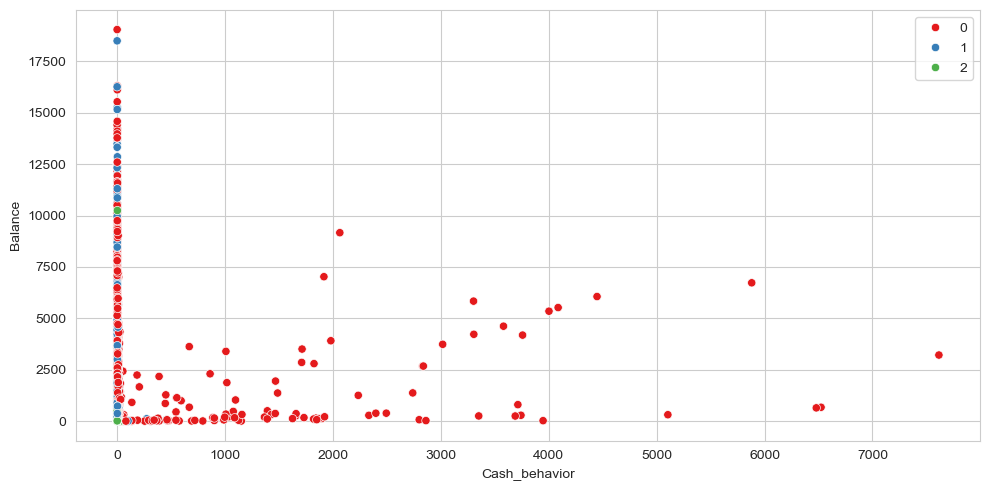

In [156]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    CBS,
    x = "Cash_behavior",
    y = "Balance",
    hue="K_Cluster",
    palette="Set1"
)
plt.legend()
plt.tight_layout()
plt.show()

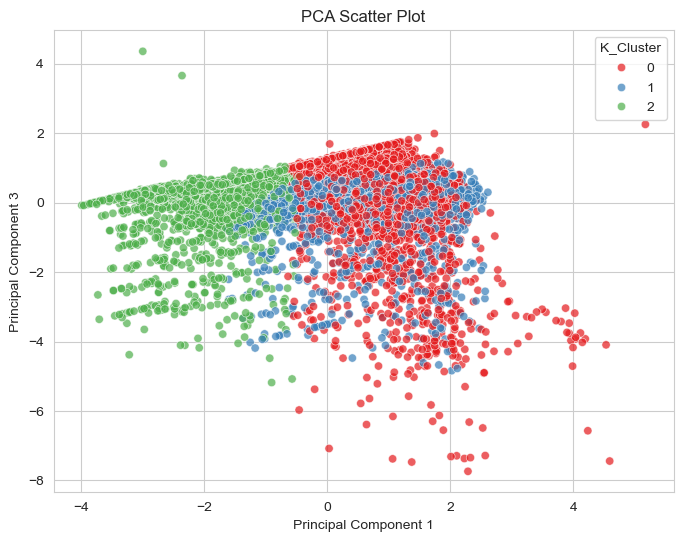

In [157]:
pca_d = PCA(n_components=6)
X_pca =pca_d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 2],palette="Set1",alpha=0.7, hue=CBS["K_Cluster"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 3")
plt.title("PCA Scatter Plot")
plt.show()

### Cluster Profile

In [158]:
Cluster_profile = CBS.groupby("K_Cluster").agg(
    Balance = ("Balance", 'mean'),
    Balance_Behavior = ("Balance_Behavior", "mean"),
    One_off_ratio = ("One_off_ratio", "mean"),
    Installment_ratio = ("Installment_ratio", "mean"),
    Cash_behavior = ("Cash_behavior", "mean"),
    Full_payment_rate = ("Full_payment_rate", "mean"),
    Tenure = ("Tenure", "mean")
).round(2)
Cluster_profile.sort_values("Installment_ratio", ascending=True)

,Balance,Balance_Behavior,One_off_ratio,Installment_ratio,Cash_behavior,Full_payment_rate,Tenure
K_Cluster,,,,,,,
1,1735.12,0.39,0.89,0.11,0.87,0.06,11.60
0,2488.11,0.65,0.07,0.36,53.18,0.02,11.46
2,147.71,0.05,0.17,0.80,0.10,0.45,11.49


In [159]:
CBS.groupby("K_Cluster").agg(
    Customer = ("K_Cluster", 'size'),
    Balance = ("Balance","sum"),
    Full_payment_rate = ("Full_payment_rate", "sum")
).round(2).assign(
    perct_customer = lambda x: (x.Customer / x.Customer.sum() * 100).round(2),
    perct_Balance = lambda x: (x.Balance / x.Balance.sum() * 100).round(2),
    perct_Full_payment_rate = lambda x: (x.Full_payment_rate / x.Full_payment_rate.sum() * 100).round(2)

)

,Customer,Balance,Full_payment_rate,perct_customer,perct_Balance,perct_Full_payment_rate
K_Cluster,,,,,,
0,3358,8355082.98,58.86,37.52,59.67,4.28
1,3037,5269561.85,175.67,33.93,37.63,12.77
2,2555,377404.88,1141.22,28.55,2.70,82.95


Isolation Forest flagged 448 anomalies out of 8950 customers


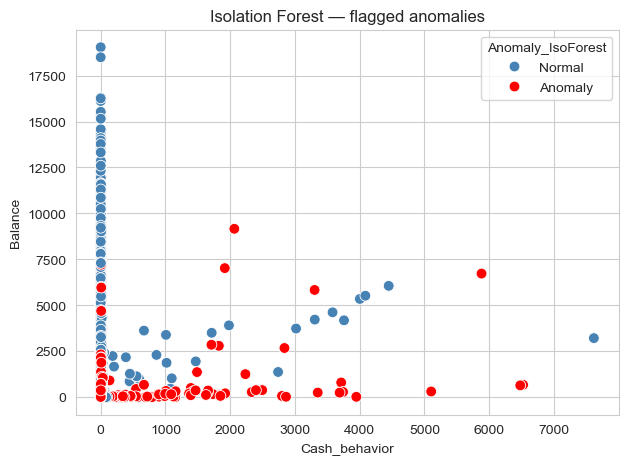

,Balance,Balance_Behavior,One_off_ratio,Installment_ratio,Cash_behavior,Full_payment_rate,Tenure,K_Cluster,Anomaly_IsoForest
CUST_ID,,,,,,,,,
C10048,474.447149,0.278922,0.000000,0.990970,5.726469,0.000000,8,0,-1
C10075,656.013010,0.093703,0.000000,0.000000,1.617573,0.250000,8,0,-1
C10104,0.000000,0.000000,0.000000,0.000000,0.646296,0.000000,7,2,-1
C10132,57.453201,0.047838,0.000000,0.000000,0.704952,0.166667,8,2,-1
C10135,69.405545,0.005338,0.000000,0.000000,2799.714934,0.000000,12,0,-1
...,...,...,...,...,...,...,...,...,...
C19186,28.493517,0.028465,0.000000,0.996577,0.000000,0.500000,6,2,-1
C19187,19.183215,0.019164,0.000000,0.996678,0.000000,0.000000,6,2,-1
C19188,23.398673,0.023375,0.000000,0.993122,0.000000,0.250000,6,2,-1


In [160]:
# B) Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)  # assume ~5% of customers are anomalies
CBS["Anomaly_IsoForest"] = iso.fit_predict(X_scaled)   # -1 = anomaly, 1 = normal

anomalies = CBS[CBS["Anomaly_IsoForest"] == -1]
print(f"Isolation Forest flagged {len(anomalies)} anomalies out of {len(CBS)} customers")

plt.figure(figsize=(7,5))
sns.scatterplot(data=CBS, x="Cash_behavior", y="Balance",
                 hue=CBS["Anomaly_IsoForest"].map({1: "Normal", -1: "Anomaly"}),
                 palette={"Normal": "steelblue", "Anomaly": "red"}, s=60)
plt.title("Isolation Forest — flagged anomalies")
plt.show()

anomalies

In [161]:
anomalies.to_csv("anomalies.csv", index=False)

In [162]:
clean_mask = CBS["Anomaly_IsoForest"] == 1
X_clean = X_scaled[clean_mask.values]

kmeans_clean = KMeans(n_clusters=k_final, random_state=42, n_init=10)
CBS.loc[clean_mask, "K_Cluster_clean"] = kmeans_clean.fit_predict(X_clean)

In [163]:
X_clean

,Balance,Balance_Behavior,One_off_ratio,Installment_ratio,Cash_behavior,Full_payment_rate,Tenure
0,-1.205218,-1.022996,-0.919551,1.327995,-0.497788,-0.556368,0.347262
1,0.948918,0.322598,-0.919551,-0.939842,0.514216,0.391958,0.347262
2,0.824993,-0.035203,1.400418,-0.939842,-0.497788,-0.556368,0.347262
3,0.624653,-0.381034,1.401465,-0.939842,5.218783,-0.556368,0.347262
4,0.271260,0.892736,1.302571,-0.939842,-0.497788,-0.556368,0.347262
...,...,...,...,...,...,...,...
8902,-1.293912,-1.093414,-0.919551,1.336100,-0.497788,1.664769,-3.377097
8909,0.150702,0.795927,1.400351,-0.939842,-0.497788,-0.556368,-3.377097
8910,-0.140869,0.033524,1.398986,-0.939842,-0.497788,-0.556368,-3.377097
8911,-1.343654,-1.062289,-0.919551,1.342763,-0.497788,-0.556368,-3.377097


### FINAL CLUSTER PROFILE: AFTER REMOVING 448 ANOMALIES DETECTED

In [164]:
Cluster_profile = CBS.groupby("K_Cluster_clean").agg(
    Balance = ("Balance", 'mean'),
    Balance_Behavior = ("Balance_Behavior", "mean"),
    One_off_ratio = ("One_off_ratio", "mean"),
    Installment_ratio = ("Installment_ratio", "mean"),
    Cash_behavior = ("Cash_behavior", "mean"),
    Full_payment_rate = ("Full_payment_rate", "mean"),
    Tenure = ("Tenure", "mean")
).round(2)
Cluster_profile.sort_values("Installment_ratio", ascending=True)

,Balance,Balance_Behavior,One_off_ratio,Installment_ratio,Cash_behavior,Full_payment_rate,Tenure
K_Cluster_clean,,,,,,,
0.0,1755.08,0.39,0.89,0.11,0.70,0.06,11.74
2.0,2554.12,0.66,0.07,0.37,18.42,0.02,11.69
1.0,149.73,0.04,0.18,0.80,0.14,0.44,11.76


### CLUSTER LABELS & BUSINESS RECOMMENDATIONS

- Cluster 2 — Cash-Advance-Dependent Revolvers
Highest balance and utilization (66% of their limit), and a cash-advance ratio nearly 26x higher than Cluster 0's — this is the group defined by leaning on cash advances rather than purchases. Full-payment rate near zero means they're carrying debt month over month.
→ Recommendation: Highest-risk, highest-revenue segment. Route to credit monitoring, not automatic limit increases. Consider a balance-transfer or debt-consolidation offer to pull them off cash-advance dependency before it becomes delinquency.

- Cluster 0 — One-Off Big-Ticket Spenders
Purchases are almost entirely one-off (89%), moderate balance, cash-advance use is low but not zero. Full-payment rate is still low (6%), so they carry balance after big purchases without relying on cash advances to do it.
→ Recommendation: Target with installment-plan conversion at point of purchase — turning their next big-ticket buy into a structured plan reduces revolving balance risk and gives you predictable repayment.

- Cluster 1 — Disciplined Low-Balance Payers
Lowest balance and utilization by a wide margin, purchases are dominantly installment-based (80%), and by far the highest full-payment rate (44% vs. 2–6% elsewhere).
→ Recommendation: Lowest risk, most underused. Good candidates for credit-limit increases and loyalty/rewards upsells — they've earned the trust and have room to spend more responsibly.

In [165]:
CBS.groupby("K_Cluster_clean").agg(
    Customer = ("K_Cluster_clean", 'size'),
    Balance = ("Balance","sum"),
    Full_payment_rate = ("Full_payment_rate", "sum")
).round(2).assign(
    perct_customer = lambda x: (x.Customer / x.Customer.sum() * 100).round(2),
    perct_Balance = lambda x: (x.Balance / x.Balance.sum() * 100).round(2),
    perct_Full_payment_rate = lambda x: (x.Full_payment_rate / x.Full_payment_rate.sum() * 100).round(2)

)

,Customer,Balance,Full_payment_rate,perct_customer,perct_Balance,perct_Full_payment_rate
K_Cluster_clean,,,,,,
0.0,2898,5086233.17,160.63,34.09,37.39,12.69
1.0,2411,361009.04,1050.40,28.36,2.65,83.01
2.0,3193,8155315.64,54.36,37.56,59.95,4.30
